## 1. Как работает RAFT-Stereo

Модель берёт левую и правую картинки и пытается понять, насколько каждый пиксель сдвинут по горизонтали.

Дальше всё происходит так:

- модель достаёт признаки из двух изображений
- сравнивает их по горизонтали
- строит начальную оценку disparity (разницы в горизонтальном положении одного и того же пикселя на левом и правом фото из стереопары)
- потом несколько раз уточняет результат
- в конце поднимает карту disparity в исходный размер

Плюсы:

- поиск идёт только по горизонтали, как и должно быть у rectified stereo ("выпрямлённая" пара стереоизображений)
- результат уточняется постепенно, а не одним грубым проходом
- модель хорошо подходит для готовых stereo pair

## 2. Как устроен репозиторий

- `demo.py` - обычный запуск на паре картинок
- `evaluate_stereo.py` - проверка на датасетах
- `train_stereo.py` - обучение
- `core/` - вся основная логика модели
- `sampler/` - ускорение через CUDA, если надо

Подробнее `core/`:

- `raft_stereo.py` - основная модель
- `corr.py` - сравнение признаков между левым и правым изображением
- `update.py` - блок который шаг за шагом улучшает disparity
- `extractor.py` - извлечение признаков
- `stereo_datasets.py` - загрузка датасетов

По сути запуск такой:

1. Загружаем модель
2. Загружаем левую и правую картинки
3. Делаем предсказание
4. Сохраняем disparity

## 3. Где это в коде

- `core/raft_stereo.py` - основной проход модели
- `core/corr.py` - горизонтальное сравнение левого и правого изображения
- `core/update.py` - итеративное улучшение результата
- `core/extractor.py` - признаки
- `core/stereo_datasets.py`- датасеты

Для этого ноутбука нам обучение не нужно. Мы используем только готовый checkpoint и делаем инференс на маленьких примерах.

In [1]:
import csv
import os
import sys
import time
import types
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
from PIL import Image
from matplotlib import pyplot as plt

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
os.chdir(repo_root)

try:
    import opt_einsum
except ModuleNotFoundError:
    fake = types.ModuleType("opt_einsum")
    fake.contract = None
    sys.modules["opt_einsum"] = fake

sys.path.append(str(repo_root / "core"))

from raft_stereo import RAFTStereo
from utils.utils import InputPadder

torch.set_grad_enabled(False)
torch.set_num_threads(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("repo_root:", repo_root)
print("device:", device)
print("torch_threads:", torch.get_num_threads())

repo_root: /home/leo/PycharmProjects/RAFT-Stereo
device: cpu
torch_threads: 1


## 4. Запуск

Здесь используются две готовые stereo pair из `Middlebury 2003`:

- `Cones`
- `Teddy`

Мы их взяли только потому, что они небольшие и подходят для примера на cpu

Вес модели: `raftstereo-middlebury.pth`.

In [2]:
model_path = repo_root / "models" / "raftstereo-middlebury.pth"
data_root = repo_root / "notebook_data" / "middlebury2003"
output_root = repo_root / "notebook_outputs" / "middlebury2003"
output_root.mkdir(parents=True, exist_ok=True)

print(model_path)
print(data_root)
print(output_root)

/home/leo/PycharmProjects/RAFT-Stereo/models/raftstereo-middlebury.pth
/home/leo/PycharmProjects/RAFT-Stereo/notebook_data/middlebury2003
/home/leo/PycharmProjects/RAFT-Stereo/notebook_outputs/middlebury2003


In [3]:
def build_args():
    return SimpleNamespace(
        mixed_precision=False,
        hidden_dims=[128, 128, 128],
        corr_implementation="alt",
        shared_backbone=False,
        corr_levels=4,
        corr_radius=4,
        n_downsample=2,
        context_norm="batch",
        slow_fast_gru=False,
        n_gru_layers=3,
    )


def load_model(checkpoint_path, device):
    model = RAFTStereo(build_args())
    state_dict = torch.load(checkpoint_path, map_location=device)
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    return model


def load_rgb_tensor(path, device):
    image = np.array(Image.open(path)).astype(np.uint8)
    if image.ndim == 2:
        image = np.repeat(image[..., None], 3, axis=2)
    return torch.from_numpy(image).permute(2, 0, 1).float()[None].to(device)


def predict_disparity(model, left_path, right_path, device, iters=16):
    image1 = load_rgb_tensor(left_path, device)
    image2 = load_rgb_tensor(right_path, device)

    padder = InputPadder(image1.shape, divis_by=32)
    image1, image2 = padder.pad(image1, image2)

    start = time.time()
    _, flow_up = model(image1, image2, iters=iters, test_mode=True)
    runtime_sec = time.time() - start

    disparity = -padder.unpad(flow_up).squeeze().cpu().numpy()
    return disparity, runtime_sec


def run_scene(model, scene_name, left_path, right_path, gt_path, output_root, device, iters=16):
    disparity, runtime_sec = predict_disparity(model, left_path, right_path, device, iters)

    scene_dir = output_root / scene_name
    scene_dir.mkdir(parents=True, exist_ok=True)

    vmin = float(np.percentile(disparity, 2))
    vmax = float(np.percentile(disparity, 98))
    if vmax <= vmin:
        vmin = float(disparity.min())
        vmax = float(disparity.max())

    np.save(scene_dir / "pred_disp.npy", disparity)
    plt.imsave(scene_dir / "pred_disp.png", disparity, cmap="jet", vmin=vmin, vmax=vmax)

    left_img = np.array(Image.open(left_path))
    gt_img = np.array(Image.open(gt_path))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
    axes[0].imshow(left_img)
    axes[0].set_title(f"{scene_name}: left image")
    axes[0].axis("off")

    pred_plot = axes[1].imshow(disparity, cmap="jet", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"Prediction ({iters} iters)")
    axes[1].axis("off")
    fig.colorbar(pred_plot, ax=axes[1], fraction=0.046, pad=0.04)

    if gt_img.ndim == 2:
        gt_plot = axes[2].imshow(gt_img, cmap="jet")
        fig.colorbar(gt_plot, ax=axes[2], fraction=0.046, pad=0.04)
    else:
        axes[2].imshow(gt_img)
    axes[2].set_title("Official disparity image")
    axes[2].axis("off")

    fig.savefig(scene_dir / "comparison.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

    return {
        "scene": scene_name,
        "iters": iters,
        "height": disparity.shape[0],
        "width": disparity.shape[1],
        "runtime_sec": round(runtime_sec, 3),
        "disp_min": float(disparity.min()),
        "disp_max": float(disparity.max()),
        "disp_mean": float(disparity.mean()),
        "artifact_dir": str(scene_dir.relative_to(repo_root)),
    }

In [4]:
model = load_model(model_path, device)

demo_iters = 4
demo_scene_names = ["cones", "teddy"]

all_scenes = {
    "cones": {
        "left": data_root / "cones" / "im2.png",
        "right": data_root / "cones" / "im6.png",
        "gt": data_root / "cones" / "disp2.png",
    },
    "teddy": {
        "left": data_root / "teddy" / "im2.png",
        "right": data_root / "teddy" / "im6.png",
        "gt": data_root / "teddy" / "disp2.png",
    },
}

rows = []
for scene_name in demo_scene_names:
    scene_paths = all_scenes[scene_name]
    row = run_scene(
        model=model,
        scene_name=scene_name,
        left_path=scene_paths["left"],
        right_path=scene_paths["right"],
        gt_path=scene_paths["gt"],
        output_root=output_root,
        device=device,
        iters=demo_iters,
    )
    rows.append(row)

with open(output_root / "summary.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

rows

/home/leo/PycharmProjects/RAFT-Stereo/core/raft_stereo.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/usr/lib/python3.14/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /build/python-pytorch/src/pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/leo/PycharmProjects/RAFT-Stereo/core/raft_stereo.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):


[{'scene': 'cones',
  'iters': 4,
  'height': 375,
  'width': 450,
  'runtime_sec': 8.456,
  'disp_min': 5.401650905609131,
  'disp_max': 113.46121978759766,
  'disp_mean': 34.54480743408203,
  'artifact_dir': 'notebook_outputs/middlebury2003/cones'},
 {'scene': 'teddy',
  'iters': 4,
  'height': 375,
  'width': 450,
  'runtime_sec': 9.233,
  'disp_min': 6.967571258544922,
  'disp_max': 86.12682342529297,
  'disp_mean': 28.170696258544922,
  'artifact_dir': 'notebook_outputs/middlebury2003/teddy'}]

Среднее время: 8.845 сек.
Артефакты: notebook_outputs/middlebury2003


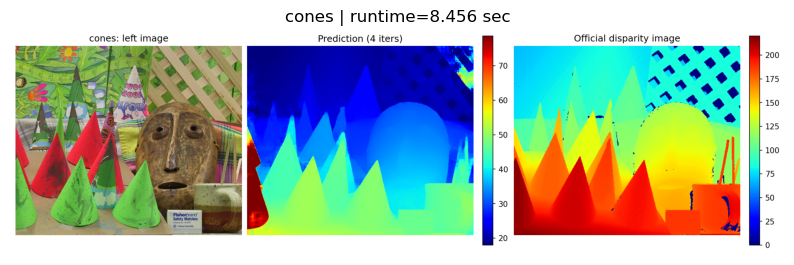

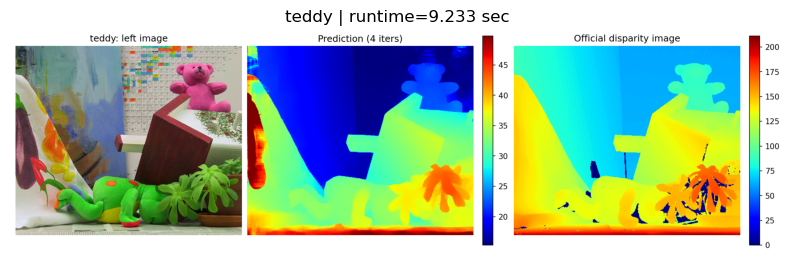

In [ ]:
avg_runtime = sum(row["runtime_sec"] for row in rows) / len(rows)
print(f"Среднее время: {avg_runtime} сек.")
print(f"Артефакты: {output_root.relative_to(repo_root)}")

for row in rows:
    comparison_path = repo_root / row["artifact_dir"] / "comparison.png"
    plt.figure(figsize=(10, 4))
    plt.imshow(Image.open(comparison_path))
    plt.title(f"{row['scene']} | runtime={row['runtime_sec']} sec")
    plt.axis("off")
    plt.show()

## 5. Что получилось

На этих двух примерах модель работает нормально и даёт плюс минус нормальную disparity-карту

К слову:

- на CPU это тоже запускается
- на маленьких картинках всё работает спокойно
- но при этом на больших изображениях лучше уже использовать GPU